In [1]:
import numpy as np
from scipy import fft
import scipy as sp
from scipy import signal
from matplotlib import pyplot as plt
from matplotlib import patches

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

# https://wirelesspi.com/a-visualization-of-causality-and-stability-in-z-transform/

## Bilateral Z-Transform

The Z-transform is the time-discrete equivalent of the Laplace transform:
It extends the discrete Fourier transform to also analyse dynamic behavior.

For a time series $x[n]$, the bilateral (or two-sided) Z-transform is defined by the following equation:


$$ X(z) = \sum_{n=-\infty}^{\infty} x[n] z^{-n} $$



$z$ is a complex number with the radius $r$:

$$z = r \ e^{j \omega}$$

For $r=1$, the Z-transform becomes the (Discrete-Time Fourier Transform) DTFT .
This is similar to the relation Laplace transform, that becomes the Fourier transform for $\sigma=0$:

$$\begin{eqnarray}
X(e^{j \omega}) & = & \sum_{n=-\infty}^{\infty} x[n]  e^{-j\omega n} \\
\end{eqnarray}$$

For all $r\neq1$, the Z-transform is:

$$\begin{eqnarray}
X(z) = X(r e^{j \omega}) & = & \sum_{n=-\infty}^{\infty} x[n] \left(r e^{j\omega}\right)^{-n}
\\
& = & \boxed{\sum_{n=-\infty}^{\infty} x[n] r^{-n}  e^{-j\omega n}} \\
\end{eqnarray}$$

Similar to the Laplace transform, the last equation shows two separate terms:

- The **decay-term $r^{-n}$**
- The **frequency-term** $e^{-j\omega n}$

-------

# Visualisation


The following plots visualize the influence of the decay term and the frequency term for the z-transform.

-----

## Changing $r$

$r$ is the decay factor. 

- For $r<1$, the transform increases with time until infinity.
- For $r>1$, the transform decreases and converges towards $0$.
- For $r=1$ we see the sine and cosine of the DTFT.



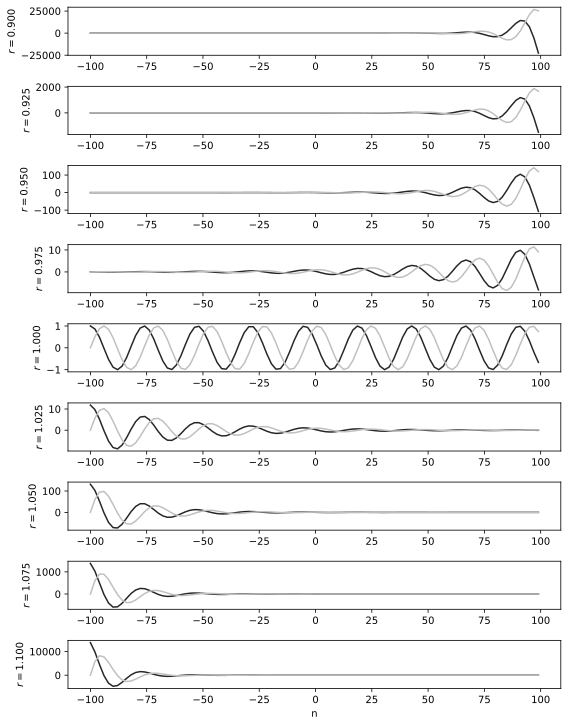

In [2]:
def z(n, r, w, real):
        
    out = np.zeros(len(n))
    
    for i in range(len(n)):

        val = n[i]
            
        if real ==1:    
            out[i] = np.real(pow(r,-val) * np.exp(-1j * w * i))
        else:
            out[i] = np.imag(pow(r,-val) * np.exp(-1j * w * i))
            
    return out

N = 100

n = np.linspace(-N,N-1,N)

fig, axs = plt.subplots(9, 1, figsize=(8, 10))

i = 0

for r in np.linspace(0.9,1.1,9):    
    # 0.1,0.2,0.3,0.5,0.7,1,1.5,2,2.53
    y = z(n,r,100,1)  
    axs[i].plot(n,y,color = [0.15,0.15,0.15])
    
    y = z(n,r, 100 ,0)
    axs[i].plot(n,y, color = [0.75,0.75,0.75])

    axs[i].set_ylabel('$r=$'+"{:2.3f}".format(r)); 
    i+=1
    
plt.tight_layout()       
plt.xlabel('n');
        
    

-----

## Changing $\omega$

The following plots show different values for $\omega$ with a fixed decay variable $r$.
This means different frequencies are *compared* with the same decay pattern.


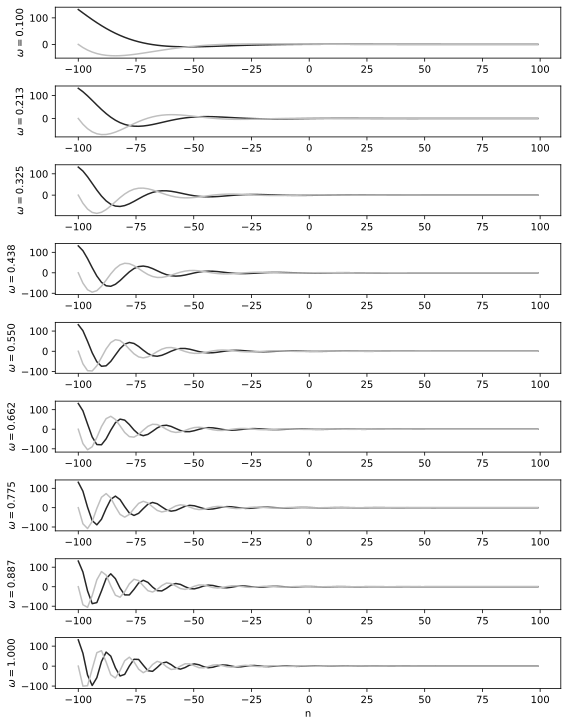

In [3]:
def z(n, r, w, real):
        
    out = np.zeros(len(n))
    
    for i in range(len(n)):
        val = n[i]
            
        if real ==1:    
            out[i] = np.real(pow(r,-val) * np.exp(-1j * w * i))
        else:
            out[i] = np.imag(pow(r,-val) * np.exp(-1j * w * i))
            
    return out

N = 100

n = np.linspace(-N,N-1,N)

fig, axs = plt.subplots(9, 1, figsize=(8, 10))

i = 0

for w in np.linspace(0.1,1,9):
    
    # 0.1,0.2,0.3,0.5,0.7,1,1.5,2,2.53
    y = z(n,1.05,w,1)  
    axs[i].plot(n,y,color = [0.15,0.15,0.15])
    
    y = z(n,1.05, w ,0)
    axs[i].plot(n,y, color = [0.75,0.75,0.75])

    axs[i].set_ylabel('$\omega=$'+"{:2.3f}".format(w)); 
    i+=1
    
plt.tight_layout()       
plt.xlabel('n');
        
    

-----

# The Z-Plane

The Z-plane is the discrete time equivalent to the S-plane for the Laplace transform.
Applying Euler, $z$ can be expressed as a combination of real and imaginary part:

$$
z = r e^{j\omega} = r \cos \varphi + r j \sin \varphi
$$



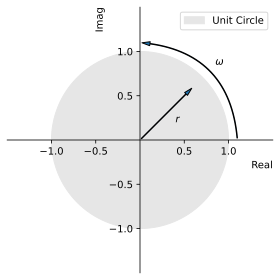

In [4]:
ax = plt.subplot(111)
ax.axis('equal')

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)

uc = patches.Circle((0,0), radius=1, fill='gray', color='gray', alpha=0.2, label='Unit Circle')
ax.add_patch(uc)

#uc = patches.Circle((0,0), radius=1, fill='', color='k', label='Unit Circle')
#ax.add_patch(uc)

a1 = patches.FancyArrowPatch((1.1, 0), (0, 1.1), connectionstyle="arc3,rad=.425", arrowstyle='Simple,tail_width=0.5, head_width=4, head_length=8')
ax.add_patch(a1)
plt.text(0.85,0.85,'$\omega$')

a1 = patches.FancyArrowPatch((0, 0), (0.6, 0.6), arrowstyle='Simple,tail_width=0.5, head_width=4, head_length=8')
ax.add_patch(a1)
plt.text(0.4,0.2,'$r$')

plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top')

plt.legend(loc=1);

The frequency $\omega$ is the angle of the complex number $z$, with the radius $r$.
A radius of $r=|z|=1$ marks the **unit circle**.


-----

## Comparison to the S Plane

The z-plane is the discrete equivalent of the s-plane. More precisely, the discrete z-plane it is a bended version of the continuos case:

- The imaginary axis of the s-plane corresponds to the unit circle.


- Vertical lines in the s-plane correspond to circles around the origin (0,0) in the z-plane. 
- Vertical lines on the left half of the s-plane are circles around the origin inside the unit circle.


- For the Laplace transform, the dashed line shows the Fourier transform with $\sigma = 0$.
- For the Z-transform, the dashed line shows the (Discrete-Time Fourier Transform) DTFT with $r = 1$.





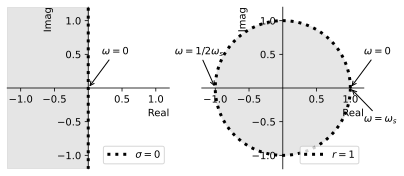

In [5]:
%run header.ipynb


ax = plt.subplot(121)


ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)

plt.fill_between([-1.2,0], [1.2,1.2],-1.2 ,  color='gray', alpha=0.2);

plt.plot( [0,0], [-2,2] , 'k:', linewidth=3, label='$\sigma = 0$')
plt.annotate("$\omega = 0$", xy=(0, 0), xytext=(0.2, 0.5), arrowprops=dict(arrowstyle="->"))

#plt.plot(-0.5,0,'xk',label='Pole');

plt.xlim(-1.2,1.2)
plt.ylim(-1.2,1.2)

plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top')

plt.legend(loc='lower right');







ax = plt.subplot(122)
ax.axis('equal')

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)

uc = patches.Circle((0,0), radius=1, fill='gray', color='gray', alpha=0.2)
ax.add_patch(uc)

#uc = plt.Circle((0,0), 1, fill=False, linestyle='--' ,color='k', label='DFT')
#ax.add_patch(uc)

theta = np.linspace( 0 , 2 * np.pi , 150 )
 
radius = 1
a = radius * np.cos( theta )
b = radius * np.sin( theta )
plt.plot( a, b , 'k:', linewidth=3,label='$r=1$')

plt.annotate("$\omega = 0$", xy=(1, 0), xytext=(1.2, 0.5), arrowprops=dict(arrowstyle="->"))
plt.annotate("$\omega = \omega_s$", xy=(1, 0), xytext=(1.2, -0.5), arrowprops=dict(arrowstyle="->"))
plt.annotate("$\omega = 1/2 \omega_s$", xy=(-1, 0), xytext=(-1.6, 0.5), arrowprops=dict(arrowstyle="->"))


plt.plot


plt.xlim(-1.2,1.2)
plt.ylim(-1.2,1.2)

plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top');

plt.legend(loc='lower right');


-----

# Region of Convergence

The Region of Convergence (ROC) of a z-transform inlcudes
all $z$ for that $X(z)$ converges:

$$
\sum_{n=−\infty}^{\infty}
|x[n]r^{-n}| < ∞
$$


- If x[n] is a finite duration sequence, then the ROC is the entire z-plane: IT MUST CONVERGE 
- The ROC cannot contain any poles (that will make more sense later).



-----


# Causality

We can observe the causality by observing the left- and right-sided part of a transform:

$$\begin{eqnarray}
X(z) & = & N(z) + P(z) \\
&=&  \sum_{n=-\infty}^{-1} x[n] \left(r e^{j\omega}\right)^{-n} +  \sum_{0}^{\infty} x[n] \left(r e^{j\omega}\right)^{-n}
\end{eqnarray}$$




-----

## Causal Signal


A causal signal is a right sided sequence - it consists only of $P(Z)$. 

The ROC of causal signals  lies outside a radius, including $|z|=\infty$.

An example for a causal function is the unit step function function:

$$
u[n] = \begin{cases} 
1, n\geq 0 \\ 
0, n < 0 \\ 
\end{cases}
$$

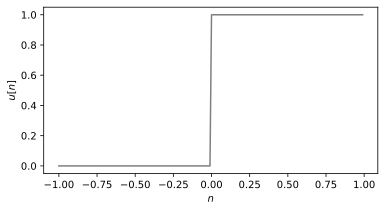

In [6]:
fig = plt.figure(figsize=(6,3))
n = np.arange(-1,1,0.01)
h = np.heaviside(n,0)
plt.plot(n,h,'gray')
plt.xlabel('$n$')
plt.ylabel('$u[n]$');


$$\begin{eqnarray}
U(z) & = & \sum_{n=0}^{\infty} u[n] z^{-n} \\
& = & \sum_{n=0}^{\infty}  z^{-n} \\
& = & \sum_{n=0}^{\infty}  \left( z^{-1} \right) ^n \\
\end{eqnarray}$$

This can be solved with a geomeric series:

$$\begin{eqnarray}
U(z) & = & \frac{1}{1-z^{-1}} \\
U(z) & = & \frac{1}{z-1} \\
\end{eqnarray}$$

- The series converges for all $|𝑧| > 1$.

- We can also see that the denominator has a root at $z = 1$ - this is referred to as a **pole**.

- The ROC of the Z-transform of the unit step sequence expands from this pole towards infinity. 

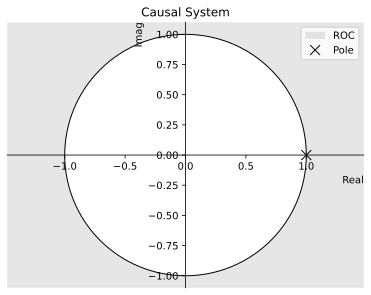

In [7]:
ax = plt.subplot(111)
ax.axis('equal')

n, radii = 50, [1, 100]

theta = np.linspace(0, 2*np.pi, n, endpoint=True)
xs = np.outer(radii, np.cos(theta))
ys = np.outer(radii, np.sin(theta))

# in order to have a closed area, the circles
# should be traversed in opposite directions
xs[1,:] = xs[1,::-1]
ys[1,:] = ys[1,::-1]

ax.fill(np.ravel(xs), np.ravel(ys),'gray', alpha=0.2, label='ROC')
plt.title('Causal System')

uc = patches.Circle((0,0), radius=1, fill='', color='k')
ax.add_patch(uc)

t2 = plt.plot(1, 0, 'xk', ms=10, label='Pole')

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top');

plt.xlim(-1.1,1.1)
plt.ylim(-1.1,1.1);


plt.legend(loc=1);

-----


## Anti-Causal Signal

An anticausal signal is a left sided sequence - it consists only of $N(Z)$. 

The ROC of such signals lies inside a radius, including $|z|=0$.

An example is the following signal:

$$\begin{eqnarray}
x[n] = -a^n u[-n-1]
\end{eqnarray}$$


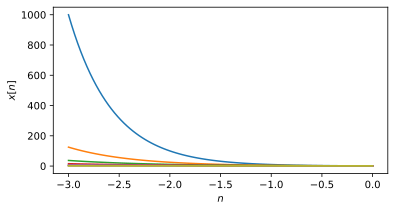

In [8]:
fig = plt.figure(figsize=(6,3));

n = np.linspace(-3,0,100)
x = np.pow(1.1,abs(n))
for i in np.arange(-0.1,-1,-0.1):
    x = np.pow(-i,n)
    plt.plot(n,x);

plt.xlabel('$n$');
plt.ylabel('$x[n]$');
plt.show();



The z-transform is:

$$\begin{eqnarray}
X(z) & = & \sum_{n=-\infty}^{-1}-a^n z^{-n} \\
 & = & \sum_{n=-\infty}^{-1}-a^n z^{-n} \\
 & = & - \sum_{n=1}^{\infty}a^{-n} z^{n} \\
 & = & 1 - \sum_{n=0}^{\infty} \left( a^{-1} z \right)^{n} \\
 &=&1-\frac{1}{1-a^{-1}z} \\
 &=&\frac{1}{1-az^{-1}} \\
\end{eqnarray}$$

To have the series converge, we need to have:

$$\begin{eqnarray}
|a^{-1}z| & < & 1 \\
|z| & < & |a| \\
\end{eqnarray}$$

- There is a pole at $|z| = |a|$.
- The ROC extends from this pole inwards.

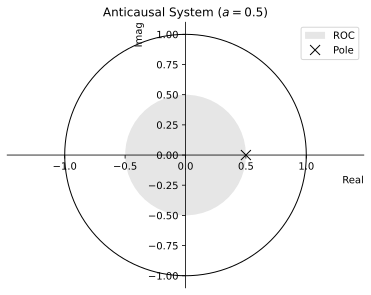

In [9]:
ax = plt.subplot(111)
ax.axis('equal')

n, radii = 50, [.5, 0]

theta = np.linspace(0, 2*np.pi, n, endpoint=True)
xs = np.outer(radii, np.cos(theta))
ys = np.outer(radii, np.sin(theta))

# in order to have a closed area, the circles
# should be traversed in opposite directions
xs[1,:] = xs[1,::-1]
ys[1,:] = ys[1,::-1]

ax.fill(np.ravel(xs), np.ravel(ys),'gray', alpha=0.2, label='ROC')
plt.title('Anticausal System ($a=0.5$)')

uc = patches.Circle((0,0), radius=1, fill='', color='k')
ax.add_patch(uc)

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

t2 = plt.plot(0.5, 0, 'xk', ms=10, label='Pole')

plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top');

plt.xlim(-1.1,1.1)
plt.ylim(-1.1,1.1)


plt.legend(loc=1);

-----

## Mixed Causality

A mixed-causal signal is defined for positive and negative $n$.

$$
x[n] = a^{|n|}
$$


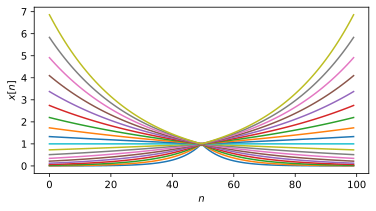

In [10]:
fig = plt.figure(figsize=(6,3));
n = np.linspace(-3,3,100)
x = np.pow(1.1,abs(n))
for i in np.arange(0.1,2,0.1):
    x = np.pow(i,abs(n))
    plt.plot(x)
plt.xlabel('$n$');
plt.ylabel('$x[n]$');
plt.show();

The ROC of such signals is a ring:

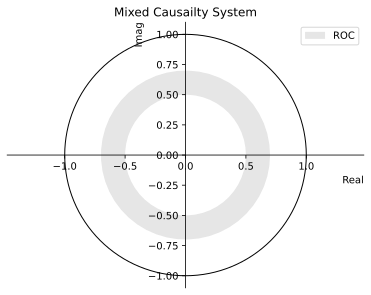

In [11]:
ax = plt.subplot(111)
ax.axis('equal')

n, radii = 50, [.5, 0.7]

theta = np.linspace(0, 2*np.pi, n, endpoint=True)
xs = np.outer(radii, np.cos(theta))
ys = np.outer(radii, np.sin(theta))

# in order to have a closed area, the circles
# should be traversed in opposite directions
xs[1,:] = xs[1,::-1]
ys[1,:] = ys[1,::-1]

ax.fill(np.ravel(xs), np.ravel(ys),'gray', alpha=0.2, label='ROC')
plt.title('Mixed Causailty System')


uc = patches.Circle((0,0), radius=1, fill='', color='k')
ax.add_patch(uc)

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top');

plt.legend(loc=1);